# Kelp Forest Oceanography — Sensor Design Analysis

Exploratory analysis of oceanographic variables inside and outside giant kelp canopy
at Monterey / Hopkins Marine Station (~36.6°N), using co-located mooring data from
BCO-DMO. Goal: identify which variables are most informative for a fixed mooring buoy
monitoring kelp forest health.

**Dataset:**
- **BCO-DMO 822549** — Hopkins kelp canopy mooring: pH, DO, temperature, salinity, PAR at
  9 depths, paired `KELP` (inside canopy) and `OUTSIDE` moorings, Jun–Oct 2018
  **Data:** [BCO-DMO Dataset 822549](https://www.bco-dmo.org/dataset/822549)
  **Source paper:** Hirsh et al. (2020), *JGR Oceans* —
  [Drivers of Biogeochemical Variability in a Central California Kelp Forest](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2020JC016320)
  DOI: 10.1029/2020JC016320

**Notebook structure:**
1. Monterey: oceanographic variables inside vs. outside canopy
2. Sensor recommendations for a fixed kelp-bed mooring

## Section 0 — Configuration & Dataset Registry

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)
plt.rcParams['figure.dpi'] = 120

# ── Dataset registry ──────────────────────────────────────────────────────
# Raw data: download mooring_inside_outside.csv from BCO-DMO dataset 822549
# at https://www.bco-dmo.org/dataset/822549 and place in data/bco_dmo/
DATASETS = {
    '822549': {
        'desc': 'Hopkins kelp canopy mooring — pH, DO, T, S, PAR at 9 depths inside/outside canopy',
        'url':  'https://www.bco-dmo.org/dataset/822549',
        'doi':  'https://doi.org/10.26008/1912/bco-dmo.822549.1',
        'site': 'Hopkins Marine Station, Monterey',
    },
}

SITE = {'lat': 36.6, 'lon': -121.9}
DATA_DIR = Path('data/bco_dmo')

print('Configuration loaded.')
print(f'Data directory: {DATA_DIR.resolve()}')

Configuration loaded.
Data directory: /Users/helenlord/Documents/github_repos/ocean-data-exploration/data/bco_dmo


## Section 1 — Monterey: Oceanographic Variables vs. Kelp Presence

Dataset **822549** (`mooring_inside_outside.csv`): 9-depth mooring pair, `KELP` (inside canopy)
vs. `OUTSIDE`, Jun–Oct 2018. Variables: pH, DO, temperature, salinity, PAR at 1–10 minute
resolution depending on sensor (Hirsh et al. 2020, Table S1).

In [2]:
# ── 1.1 Load mooring inside/outside (822549) ─────────────────────────────
# Primary dataset: 9-depth paired mooring, KELP vs OUTSIDE, Jun-Oct 2018.
# 'nd' in raw CSV encodes missing values.
moor_path = DATA_DIR / 'mooring_inside_outside.csv'
df_moor = pd.read_csv(moor_path, na_values='nd')
df_moor['datetime'] = pd.to_datetime(df_moor['ISO_DateTime_UTC'], utc=True)

print(f'Mooring data: {df_moor.shape}')
print(f'Moorings: {sorted(df_moor["Mooring_ID"].unique())}')
print(f'Depth IDs: {sorted(df_moor["Depth_ID"].unique())}')
print(f'Date range: {df_moor["datetime"].min()} → {df_moor["datetime"].max()}')
print()
print('Column names (confirm units against BCO-DMO data dictionary):')
print(df_moor.columns.tolist())
print()
print(df_moor.groupby('Mooring_ID').agg(
    n_rows=('Temperature','count'),
    mab_min=('MAB','min'),
    mab_max=('MAB','max'),
    temp_mean=('Temperature','mean'),
).round(2).to_string())

Mooring data: (617562, 14)
Moorings: ['KELP', 'OUTSIDE']
Depth IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Date range: 2018-06-07 16:00:00+00:00 → 2018-10-04 19:00:00+00:00

Column names (confirm units against BCO-DMO data dictionary):
['Depth_ID', 'Mooring_ID', 'Latitude', 'Longitude', 'MAB', 'pH', 'DO', 'DOSAT', 'Temperature', 'Salinity', 'Pressure', 'PAR', 'ISO_DateTime_UTC', 'datetime']

            n_rows  mab_min  mab_max  temp_mean
Mooring_ID                                     
KELP        285275      0.0    11.15      13.66
OUTSIDE     278120      0.0    18.95      13.42


In [3]:
# ── 1.2 Sensor depth map ─────────────────────────────────────────────────
# Establishes absolute depth from surface for each sensor on each mooring,
# and identifies which variables are measured where.
# Site depth derived from bottom sensor (MAB=0) pressure reading.

# DO units: μmol/kg — confirmed from data values (~200–280 range, consistent only with
# μmol/kg; mg/L would be ~6–9, mL/L would be ~4–7). CSV header has no units row.
# DOSAT (percent saturation) is present in the CSV but not analyzed here — both DO
# and DOSAT come from the same optode sensor; analysis focuses on inside-vs-outside
# concentration differences (DO) rather than saturation state.
VARS = ['Temperature', 'pH', 'DO', 'Salinity', 'PAR']

# Site total depth from bottom sensor pressure
site_depth_m = (df_moor[df_moor['MAB'] == 0.0]
                .groupby('Mooring_ID')['Pressure'].median())

# Absolute depth from surface = site_depth - MAB
depth_map = (df_moor.groupby(['Mooring_ID', 'Depth_ID'])['MAB']
             .median().reset_index())
depth_map['site_depth'] = depth_map['Mooring_ID'].map(site_depth_m)
depth_map['depth_m'] = (depth_map['site_depth'] - depth_map['MAB']).round(2)

# Count non-null observations per sensor per variable
obs_counts = df_moor.groupby(['Mooring_ID', 'Depth_ID'])[VARS].count()

# Build readable sensor map
print('Sensor depth map — absolute depth from surface (m) and variables measured')
print('(✓ = >100 observations, — = no data at this sensor)\n')
for mooring in ['KELP', 'OUTSIDE']:
    sub = depth_map[depth_map['Mooring_ID'] == mooring].sort_values('depth_m')
    print(f'{mooring} mooring (site depth ≈ {site_depth_m[mooring]:.1f}m):')
    print(f'  {"Depth(m)":<10}' + ''.join(f'{v:<12}' for v in VARS))
    for _, row in sub.iterrows():
        did = int(row['Depth_ID'])
        d = row['depth_m']
        vals = []
        for v in VARS:
            n = obs_counts.loc[(mooring, did), v] if (mooring, did) in obs_counts.index else 0
            vals.append('✓' if n > 100 else '—')
        print(f'  {d:<10.1f}' + ''.join(f'{v:<12}' for v in vals))
    print()

print('PAR note: both moorings measure PAR only at the bottom sensor.')
print(f'  KELP bottom = {site_depth_m["KELP"]:.1f}m depth, '
      f'OUTSIDE bottom = {site_depth_m["OUTSIDE"]:.1f}m depth.')
print('  These are different absolute depths — cannot be directly compared.')
print()
print('pH sensor coverage note (Hirsh et al. 2020, Table S1):')
print('  KELP mooring has NO pH sensor above 3.8m from surface.')
print('  The 0–3.8m surface layer — where photosynthetic pH elevation is expected')
print('  to be strongest — is uninstrumented for pH inside the kelp forest.')
print(f'  OUTSIDE pH sensor: 3.1m from surface in a {site_depth_m["OUTSIDE"]:.1f}m water column (near-surface).')
print(f'  KELP pH sensors:   3.8–8.9m from surface in a {site_depth_m["KELP"]:.1f}m water column (mid-to-bottom).')
print('  Any KELP–OUTSIDE pH comparison from this dataset is sub-canopy vs.')
print('  near-surface open water — not a depth-equivalent inside vs. outside comparison.')

def get_depth(mooring, depth_id):
    return float(depth_map.loc[
        (depth_map['Mooring_ID'] == mooring) & (depth_map['Depth_ID'] == depth_id),
        'depth_m'].values[0])

Sensor depth map — absolute depth from surface (m) and variables measured
(✓ = >100 observations, — = no data at this sensor)

KELP mooring (site depth ≈ 9.9m):
  Depth(m)  Temperature pH          DO          Salinity    PAR         
  0.0       ✓           —           ✓           —           —           
  3.8       ✓           ✓           ✓           ✓           —           
  4.7       ✓           ✓           ✓           —           —           
  5.5       ✓           ✓           —           ✓           —           
  6.6       ✓           ✓           ✓           —           —           
  7.3       ✓           ✓           —           —           —           
  8.4       ✓           ✓           —           —           —           
  8.9       ✓           ✓           ✓           ✓           —           
  9.9       ✓           —           —           —           ✓           

OUTSIDE mooring (site depth ≈ 17.7m):
  Depth(m)  Temperature pH          DO          Salinity    PAR       

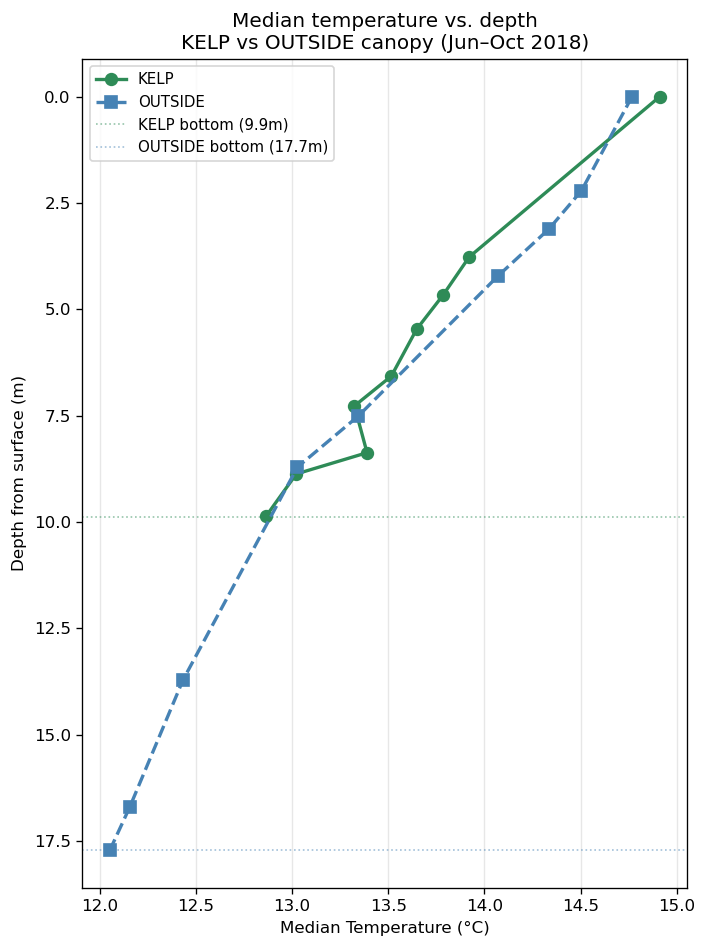

In [4]:
# ── 1.3 Temperature depth profile ────────────────────────────────────────
# Temperature is the only variable with full 9-sensor coverage on both moorings.
# Y-axis: absolute depth from surface (computed in 1.2).
# Both moorings plotted together — KELP site ends at 9.9m, OUTSIDE at 17.7m.

temp_prof = (df_moor.groupby(['Mooring_ID', 'Depth_ID'])['Temperature']
             .median().reset_index()
             .merge(depth_map[['Mooring_ID','Depth_ID','depth_m']],
                    on=['Mooring_ID','Depth_ID']))

fig, ax = plt.subplots(figsize=(6, 8))
for mooring, color, ls, marker in [
    ('KELP',    'seagreen',  '-',  'o'),
    ('OUTSIDE', 'steelblue', '--', 's'),
]:
    sub = temp_prof[temp_prof['Mooring_ID'] == mooring].sort_values('depth_m')
    ax.plot(sub['Temperature'], sub['depth_m'],
            color=color, ls=ls, lw=2, marker=marker, ms=7, label=mooring)

ax.invert_yaxis()
ax.set_xlabel('Median Temperature (°C)')
ax.set_ylabel('Depth from surface (m)')
ax.axhline(site_depth_m['KELP'],    color='seagreen',  ls=':', alpha=0.5, lw=1,
           label=f'KELP bottom ({site_depth_m["KELP"]:.1f}m)')
ax.axhline(site_depth_m['OUTSIDE'], color='steelblue', ls=':', alpha=0.5, lw=1,
           label=f'OUTSIDE bottom ({site_depth_m["OUTSIDE"]:.1f}m)')
ax.legend(fontsize=9)
ax.set_title('Median temperature vs. depth\nKELP vs OUTSIDE canopy (Jun–Oct 2018)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

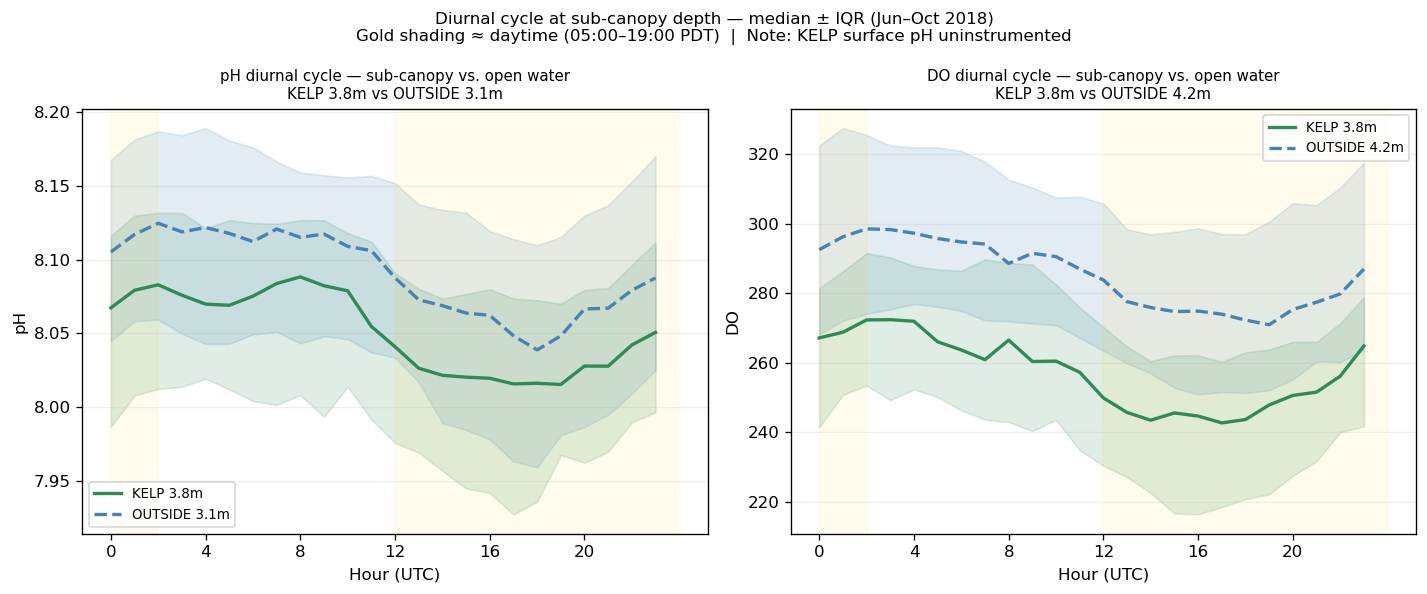

Diurnal amplitude (max − min of hourly median):
  pH    KELP 3.8m:    0.0728
  pH    OUTSIDE 3.1m: 0.0858
  DO    KELP 3.8m:    29.7147
  DO    OUTSIDE 4.2m: 27.5972

Day vs. night mean:
  Period  Variable Depths                      KELP   OUTSIDE   Δ(K−O)
  ──────────────────────────────────────────────────────────────
  Day     pH     K 3.8m / O 3.1m           8.0258    8.0688  -0.0430
  Day     DO     K 3.8m / O 4.2m         249.4266  282.1746 -32.7481
  Night   pH     K 3.8m / O 3.1m           8.0669    8.1101  -0.0432
  Night   DO     K 3.8m / O 4.2m         266.8158  297.0029 -30.1871

Flat day/night Δ indicates the kelp metabolic signal does not penetrate to
sub-canopy depth — consistent with Hirsh et al. (2020), who find the kelp
canopy effect is limited to a surface layer of ~1–5m. Physical drivers
(upwelling, internal bores, light attenuation) dominate at 3.8m and below.
Whether the uninstrumented surface layer (<3.8m) shows a diel pH signal
consistent with photosynthesis ca

In [5]:
# ── 1.4 Diurnal pH and DO at available sensor pairs ──────────────────────
# Tests whether the sub-canopy pH/DO deficit varies by time of day.
# As noted in 1.2, KELP has no pH sensor above 3.8m — the surface layer
# where photosynthetic elevation is expected is uninstrumented.
# This analysis describes the sub-canopy zone (3.8m+), not the canopy surface.
#
# Pairs used:
#   pH:  KELP DID2 (3.8m)  ↔  OUTSIDE DID3 (3.1m)   only available pH pair
#   DO:  KELP DID2 (3.8m)  ↔  OUTSIDE DID4 (4.2m)   shallowest available DO pair
#
# If the sub-canopy pH deficit narrows during the day: some photosynthetic
# signal reaches 3.8m depth inside the forest.
# If flat across the diurnal cycle: canopy shading and physical advection
# dominate at this depth — the kelp metabolic signal does not penetrate
# below the surface canopy layer (~1-5m), consistent with Hirsh et al. (2020).

df_moor['hour_utc'] = df_moor['datetime'].dt.hour

DIURNAL_PAIRS = [
    ('pH', 'KELP', 2, 'OUTSIDE', 3),
    ('DO', 'KELP', 2, 'OUTSIDE', 4),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (var, km, kid, om, oid) in zip(axes, DIURNAL_PAIRS):
    kd = get_depth(km, kid)
    od = get_depth(om, oid)

    k_sub = df_moor[(df_moor['Mooring_ID'] == km) & (df_moor['Depth_ID'] == kid)]
    o_sub = df_moor[(df_moor['Mooring_ID'] == om) & (df_moor['Depth_ID'] == oid)]

    k_med = k_sub.groupby('hour_utc')[var].median()
    o_med = o_sub.groupby('hour_utc')[var].median()
    k_q25 = k_sub.groupby('hour_utc')[var].quantile(0.25)
    k_q75 = k_sub.groupby('hour_utc')[var].quantile(0.75)
    o_q25 = o_sub.groupby('hour_utc')[var].quantile(0.25)
    o_q75 = o_sub.groupby('hour_utc')[var].quantile(0.75)

    ax.plot(k_med.index, k_med.values, color='seagreen',  lw=2,
            label=f'KELP {kd:.1f}m')
    ax.fill_between(k_med.index, k_q25.values, k_q75.values,
                    color='seagreen', alpha=0.15)
    ax.plot(o_med.index, o_med.values, color='steelblue', lw=2, ls='--',
            label=f'OUTSIDE {od:.1f}m')
    ax.fill_between(o_med.index, o_q25.values, o_q75.values,
                    color='steelblue', alpha=0.15)

    # Approximate daytime: UTC 12–02 ≈ 05:00–19:00 PDT (PDT = UTC−7)
    ax.axvspan(12, 24, color='gold', alpha=0.07)
    ax.axvspan(0,   2, color='gold', alpha=0.07)
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel(var)
    ax.set_title(f'{var} diurnal cycle — sub-canopy vs. open water\n'
                 f'KELP {kd:.1f}m vs OUTSIDE {od:.1f}m', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xticks(range(0, 24, 4))
    ax.grid(axis='y', alpha=0.2)

plt.suptitle(
    'Diurnal cycle at sub-canopy depth — median ± IQR (Jun–Oct 2018)\n'
    'Gold shading ≈ daytime (05:00–19:00 PDT)  |  Note: KELP surface pH uninstrumented',
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Day / night split ──────────────────────────────────────────────────────
PERIODS = {
    'Day':   list(range(12, 24)) + list(range(0, 2)),
    'Night': list(range(2, 12)),
}

print('Diurnal amplitude (max − min of hourly median):')
for var, km, kid, om, oid in DIURNAL_PAIRS:
    kd = get_depth(km, kid)
    od = get_depth(om, oid)
    k_amp = (df_moor[(df_moor['Mooring_ID']==km) & (df_moor['Depth_ID']==kid)]
             .groupby('hour_utc')[var].median())
    o_amp = (df_moor[(df_moor['Mooring_ID']==om) & (df_moor['Depth_ID']==oid)]
             .groupby('hour_utc')[var].median())
    print(f'  {var:<4}  KELP {kd:.1f}m:    {k_amp.max()-k_amp.min():.4f}')
    print(f'  {var:<4}  OUTSIDE {od:.1f}m: {o_amp.max()-o_amp.min():.4f}')
print()

print('Day vs. night mean:')
print(f'  {"Period":<7} {"Variable":<6} {"Depths":<22} {"KELP":>9} {"OUTSIDE":>9} {"Δ(K−O)":>8}')
print('  ' + '─' * 62)
for period, hours in PERIODS.items():
    sub = df_moor[df_moor['hour_utc'].isin(hours)]
    for var, km, kid, om, oid in DIURNAL_PAIRS:
        kd = get_depth(km, kid)
        od = get_depth(om, oid)
        k_m = sub.loc[(sub['Mooring_ID']==km) & (sub['Depth_ID']==kid), var].dropna().mean()
        o_m = sub.loc[(sub['Mooring_ID']==om) & (sub['Depth_ID']==oid), var].dropna().mean()
        depths = f'K {kd:.1f}m / O {od:.1f}m'
        print(f'  {period:<7} {var:<6} {depths:<22} {k_m:>9.4f} {o_m:>9.4f} {k_m-o_m:>+8.4f}')
print()
print('Flat day/night Δ indicates the kelp metabolic signal does not penetrate to')
print('sub-canopy depth — consistent with Hirsh et al. (2020), who find the kelp')
print('canopy effect is limited to a surface layer of ~1–5m. Physical drivers')
print('(upwelling, internal bores, light attenuation) dominate at 3.8m and below.')
print('Whether the uninstrumented surface layer (<3.8m) shows a diel pH signal')
print('consistent with photosynthesis cannot be determined from this dataset alone.')

### Bore dynamics and spike asymmetry — context for sections 1.5–1.7

Large spikes in the difference time series reflect **internal tidal bores** (Hirsh et al., 2020): semidiurnal pulses of cold, low-O2, low-pH water that arrive at OUTSIDE first and reach KELP delayed and canopy-dampened. OUTSIDE DO and pH are more variable (~23% and ~6% larger std) consistent with this dampening, but mean DO and pH are *lower inside* because canopy shading independently suppresses sub-canopy photosynthesis — spike variability and seasonal mean offset are two different effects. Salinity spikes are larger at KELP (~48% larger std), but this is sensor geometry: the KELP sensor sits 6.1m above the seafloor vs. 13.5m at OUTSIDE, placing it closer to where dense bore water intrudes along the bottom. Temperature shows no spike asymmetry between sites.

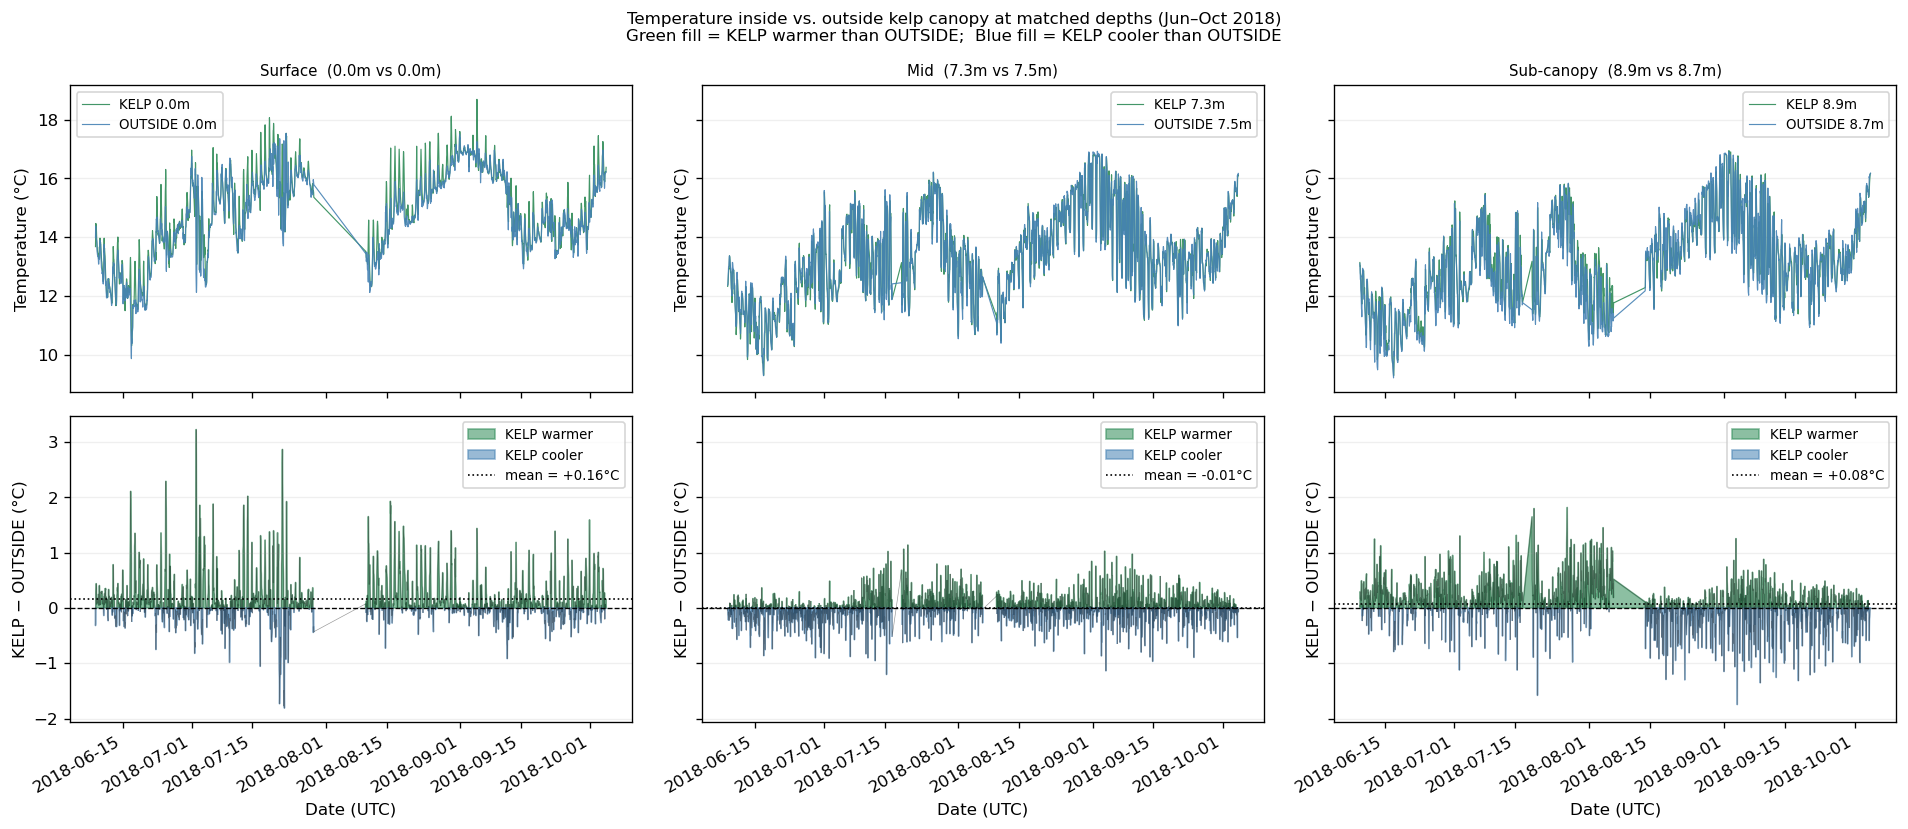

In [6]:
# ── 1.5 Temperature at matched depths: KELP vs OUTSIDE ───────────────────
# Analysis capped at KELP site depth (~9.9m): only depths with sensors on
# both moorings are compared. Three best-matched temperature pairs (from 1.2).
#
# Matched pairs used:
#   Surface:     KELP DID1  0.0m  ↔  OUTSIDE DID1  0.0m  (Δ=0.0m)
#   Mid:         KELP DID6  7.3m  ↔  OUTSIDE DID5  7.5m  (Δ=0.2m)
#   Sub-canopy:  KELP DID8  8.9m  ↔  OUTSIDE DID6  8.7m  (Δ=0.2m)
#                Note: 8.9m is near the base of the KELP site (9.9m total);
#                the OUTSIDE mooring extends to 17.7m — this is mid-column there.

# Hourly means — df_t and get_series() also used in 1.6
df_t = (df_moor.dropna(subset=['Temperature'])
        .groupby(['Mooring_ID', 'Depth_ID',
                  pd.Grouper(key='datetime', freq='1h')])['Temperature']
        .mean().reset_index())
df_t = df_t.merge(
    depth_map[['Mooring_ID', 'Depth_ID', 'depth_m']],
    on=['Mooring_ID', 'Depth_ID']
)

MATCHED_TEMP = [
    ('KELP', 1, 'OUTSIDE', 1, 'Surface',     '0.0m vs 0.0m'),
    ('KELP', 6, 'OUTSIDE', 5, 'Mid',         '7.3m vs 7.5m'),
    ('KELP', 8, 'OUTSIDE', 6, 'Sub-canopy',  '8.9m vs 8.7m'),
]

def get_series(mooring, did):
    return (df_t[(df_t['Mooring_ID'] == mooring) & (df_t['Depth_ID'] == did)]
            .set_index('datetime').sort_index()['Temperature'])

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex='col', sharey='row')

for col, (km, kid, om, oid, label, depth_label) in enumerate(MATCHED_TEMP):
    kd = float(depth_map.loc[(depth_map['Mooring_ID']==km) &
                              (depth_map['Depth_ID']==kid), 'depth_m'].values[0])
    od = float(depth_map.loc[(depth_map['Mooring_ID']==om) &
                              (depth_map['Depth_ID']==oid), 'depth_m'].values[0])

    k_ser = get_series(km, kid)
    o_ser = get_series(om, oid)
    common = k_ser.index.intersection(o_ser.index)
    k_al   = k_ser.reindex(common)
    o_al   = o_ser.reindex(common)
    diff   = k_al - o_al

    # ── Top row: raw temperatures overlaid ───────────────────────────────
    ax_t = axes[0, col]
    ax_t.plot(k_al.index, k_al.values, color='seagreen',  lw=0.7, alpha=0.9,
              label=f'KELP {kd:.1f}m')
    ax_t.plot(o_al.index, o_al.values, color='steelblue', lw=0.7, alpha=0.9,
              label=f'OUTSIDE {od:.1f}m')
    ax_t.set_title(f'{label}  ({depth_label})', fontsize=9)
    ax_t.set_ylabel('Temperature (°C)')
    ax_t.legend(fontsize=8)
    ax_t.grid(axis='y', alpha=0.2)

    # ── Bottom row: KELP − OUTSIDE difference ─────────────────────────────
    # Fills drawn first so the line sits on top without obscuring the color.
    ax_d = axes[1, col]
    ax_d.fill_between(diff.index, diff.values, 0,
                      where=(diff.values >= 0), color='seagreen',  alpha=0.55,
                      label='KELP warmer')
    ax_d.fill_between(diff.index, diff.values, 0,
                      where=(diff.values <  0), color='steelblue', alpha=0.55,
                      label='KELP cooler')
    ax_d.plot(diff.index, diff.values, color='k', lw=0.4, alpha=0.4)
    ax_d.axhline(0,           color='k',   lw=0.8, ls='--')
    ax_d.axhline(diff.mean(), color='k',   lw=1.0, ls=':',
                 label=f'mean = {diff.mean():+.2f}°C')
    ax_d.set_ylabel('KELP − OUTSIDE (°C)')
    ax_d.set_xlabel('Date (UTC)')
    ax_d.legend(fontsize=8)
    ax_d.grid(axis='y', alpha=0.2)

fig.autofmt_xdate()
plt.suptitle(
    'Temperature inside vs. outside kelp canopy at matched depths (Jun–Oct 2018)\n'
    'Green fill = KELP warmer than OUTSIDE;  Blue fill = KELP cooler than OUTSIDE',
    fontsize=10
)
plt.tight_layout()
plt.show()

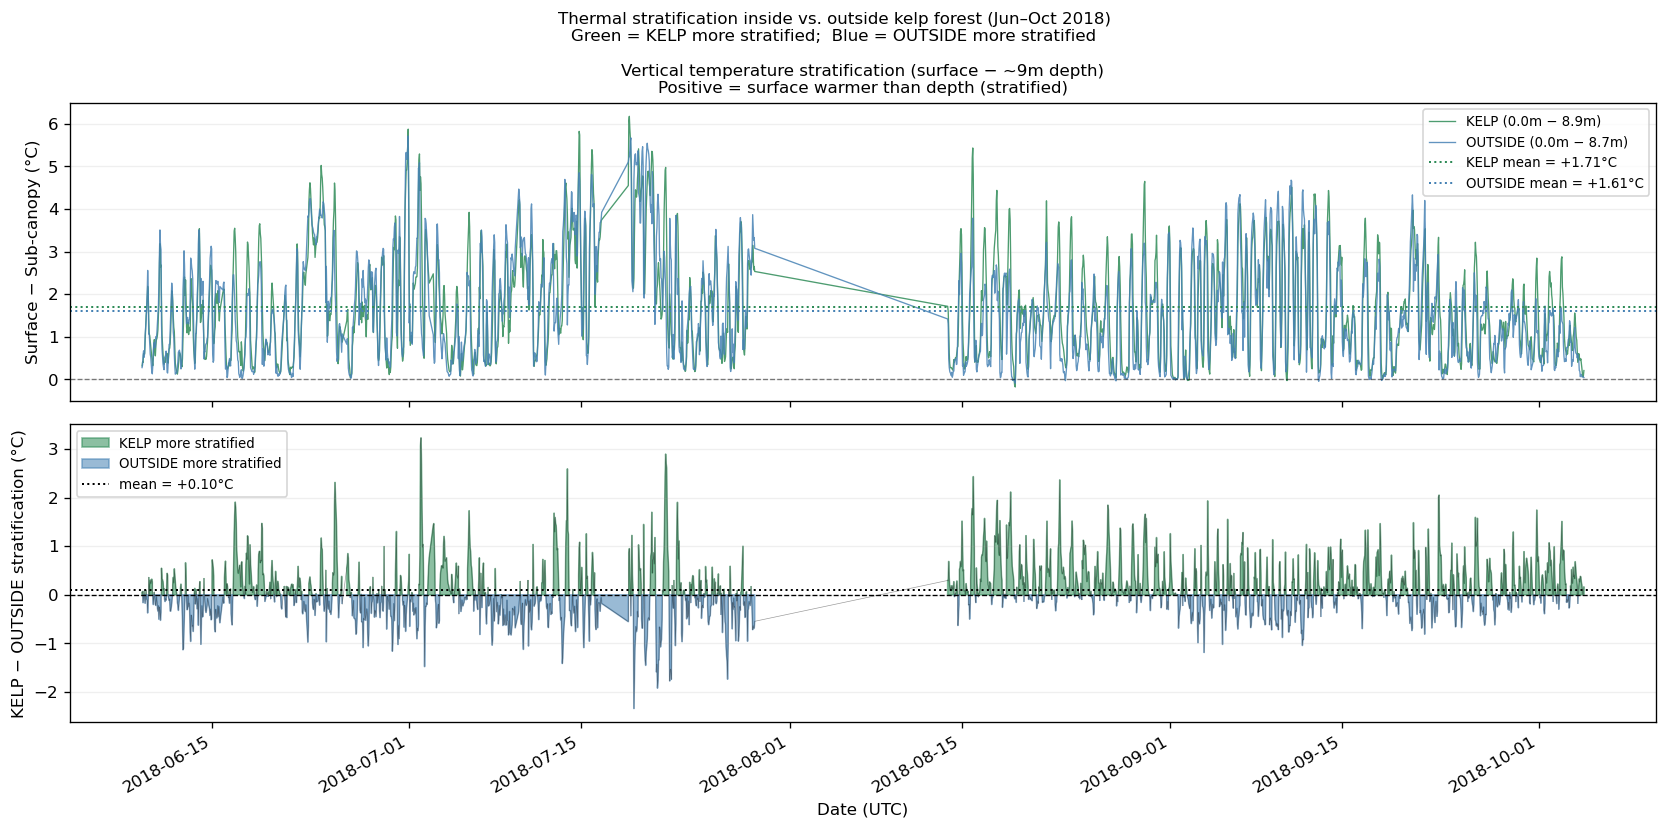

Stratification summary — surface minus sub-canopy temperature (°C):
                          Mean    Std      p5  Median     p95
  ───────────────────────────────────────────────────────
  KELP                   +1.71   1.21    +0.22   +1.47   +3.99
  OUTSIDE                +1.61   1.24    +0.11   +1.36   +3.94
  KELP − OUTSIDE         +0.10   0.57    -0.68   +0.03   +1.14

Stratification is comparable between sites (mean KELP − OUTSIDE ≈ 0°C),
confirming that temperature differences in this dataset are physically driven
rather than kelp-metabolic. This supports ranking temperature last in sensor
priority in Section 2 — it adds physical context but is not a kelp signal.


In [7]:
# ── 1.6 Vertical temperature stratification: surface − sub-canopy ─────────
# Stratification = surface temperature minus sub-canopy temperature.
# Positive = surface warmer than depth (stratified). Negative = mixed/inverted.
#
# Both spans cover ~9m of water column, making them directly comparable:
#   KELP:    DID1 (0.0m) − DID8 (8.9m)
#   OUTSIDE: DID1 (0.0m) − DID6 (8.7m)
#
# Purpose: characterise whether the kelp forest maintains different thermal
# stratification than open water over the same depth range.

k_surf = get_series('KELP',    1)
k_deep = get_series('KELP',    8)
o_surf = get_series('OUTSIDE', 1)
o_deep = get_series('OUTSIDE', 6)

common_k = k_surf.index.intersection(k_deep.index)
common_o = o_surf.index.intersection(o_deep.index)
common   = common_k.intersection(common_o)

k_strat    = (k_surf.reindex(common) - k_deep.reindex(common)).rename('KELP')
o_strat    = (o_surf.reindex(common) - o_deep.reindex(common)).rename('OUTSIDE')
diff_strat = k_strat - o_strat

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── Top: raw stratification time series ───────────────────────────────────
ax = axes[0]
ax.plot(k_strat.index, k_strat.values, color='seagreen',  lw=0.8, alpha=0.85,
        label='KELP (0.0m − 8.9m)')
ax.plot(o_strat.index, o_strat.values, color='steelblue', lw=0.8, alpha=0.85,
        label='OUTSIDE (0.0m − 8.7m)')
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.axhline(k_strat.mean(), color='seagreen',  lw=1.2, ls=':',
           label=f'KELP mean = {k_strat.mean():+.2f}°C')
ax.axhline(o_strat.mean(), color='steelblue', lw=1.2, ls=':',
           label=f'OUTSIDE mean = {o_strat.mean():+.2f}°C')
ax.set_ylabel('Surface − Sub-canopy (°C)')
ax.set_title(
    'Vertical temperature stratification (surface − ~9m depth)\n'
    'Positive = surface warmer than depth (stratified)',
    fontsize=10
)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.2)

# ── Bottom: KELP − OUTSIDE stratification difference ─────────────────────
ax2 = axes[1]
ax2.fill_between(diff_strat.index, diff_strat.values, 0,
                 where=(diff_strat.values >= 0), color='seagreen',  alpha=0.55,
                 label='KELP more stratified')
ax2.fill_between(diff_strat.index, diff_strat.values, 0,
                 where=(diff_strat.values <  0), color='steelblue', alpha=0.55,
                 label='OUTSIDE more stratified')
ax2.plot(diff_strat.index, diff_strat.values, color='k', lw=0.4, alpha=0.4)
ax2.axhline(0,                 color='k', lw=0.8, ls='--')
ax2.axhline(diff_strat.mean(), color='k', lw=1.2, ls=':',
            label=f'mean = {diff_strat.mean():+.2f}°C')
ax2.set_ylabel('KELP − OUTSIDE stratification (°C)')
ax2.set_xlabel('Date (UTC)')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.2)

fig.autofmt_xdate()
plt.suptitle(
    'Thermal stratification inside vs. outside kelp forest (Jun–Oct 2018)\n'
    'Green = KELP more stratified;  Blue = OUTSIDE more stratified',
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Summary statistics ─────────────────────────────────────────────────────
print('Stratification summary — surface minus sub-canopy temperature (°C):')
print(f'  {"":20} {"Mean":>7} {"Std":>6} {"p5":>7} {"Median":>7} {"p95":>7}')
print('  ' + '─' * 55)
for label, s in [('KELP', k_strat), ('OUTSIDE', o_strat), ('KELP − OUTSIDE', diff_strat)]:
    print(f'  {label:<20} {s.mean():>+7.2f} {s.std():>6.2f}'
          f'  {s.quantile(0.05):>+7.2f} {s.median():>+7.2f} {s.quantile(0.95):>+7.2f}')
print()
print('Stratification is comparable between sites (mean KELP − OUTSIDE ≈ 0°C),')
print('confirming that temperature differences in this dataset are physically driven')
print('rather than kelp-metabolic. This supports ranking temperature last in sensor')
print('priority in Section 2 — it adds physical context but is not a kelp signal.')

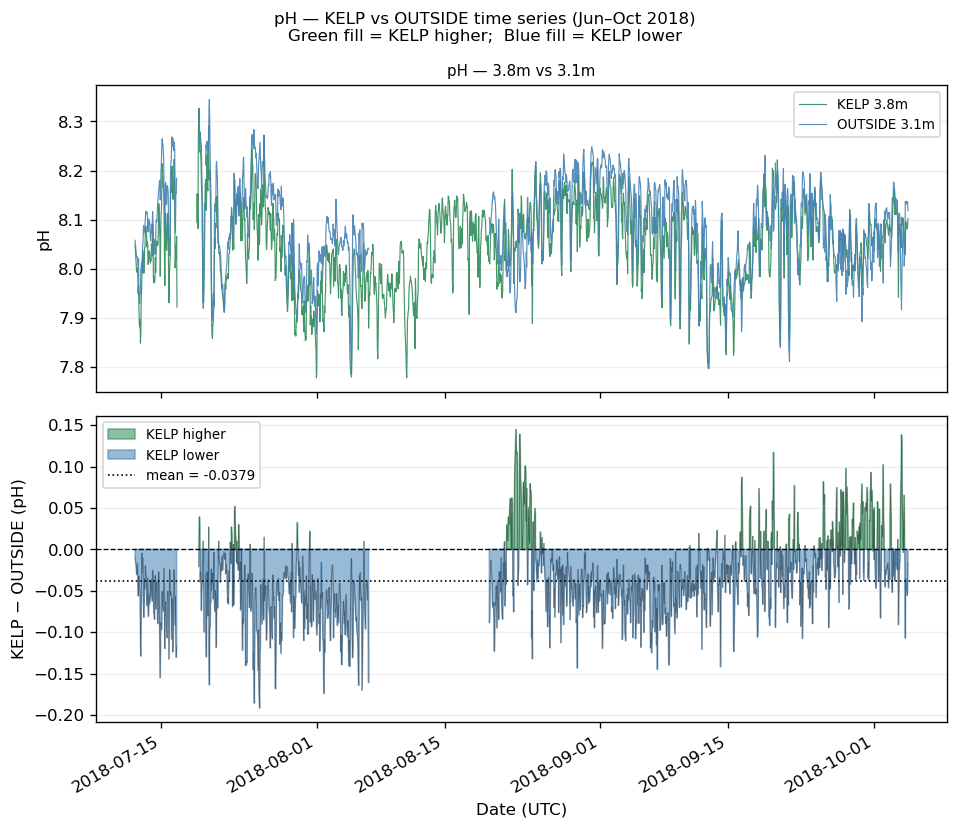

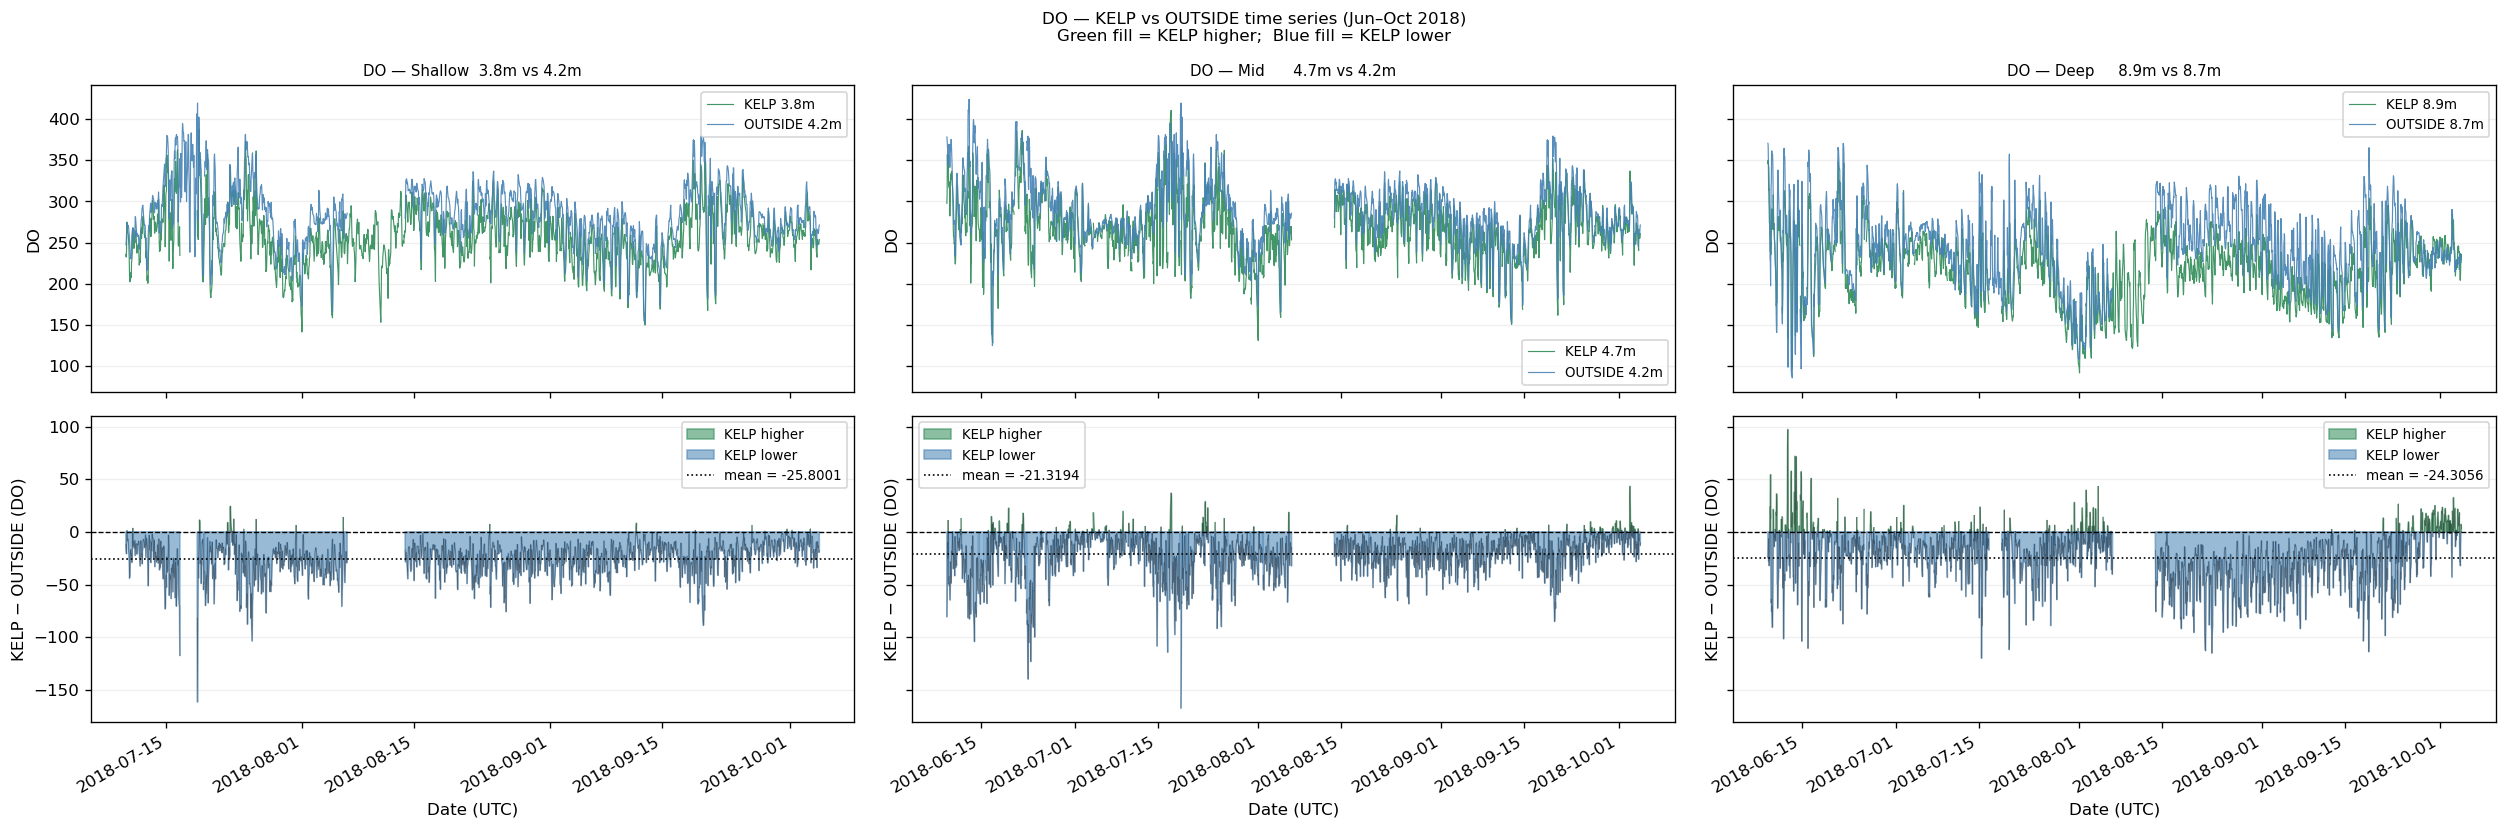

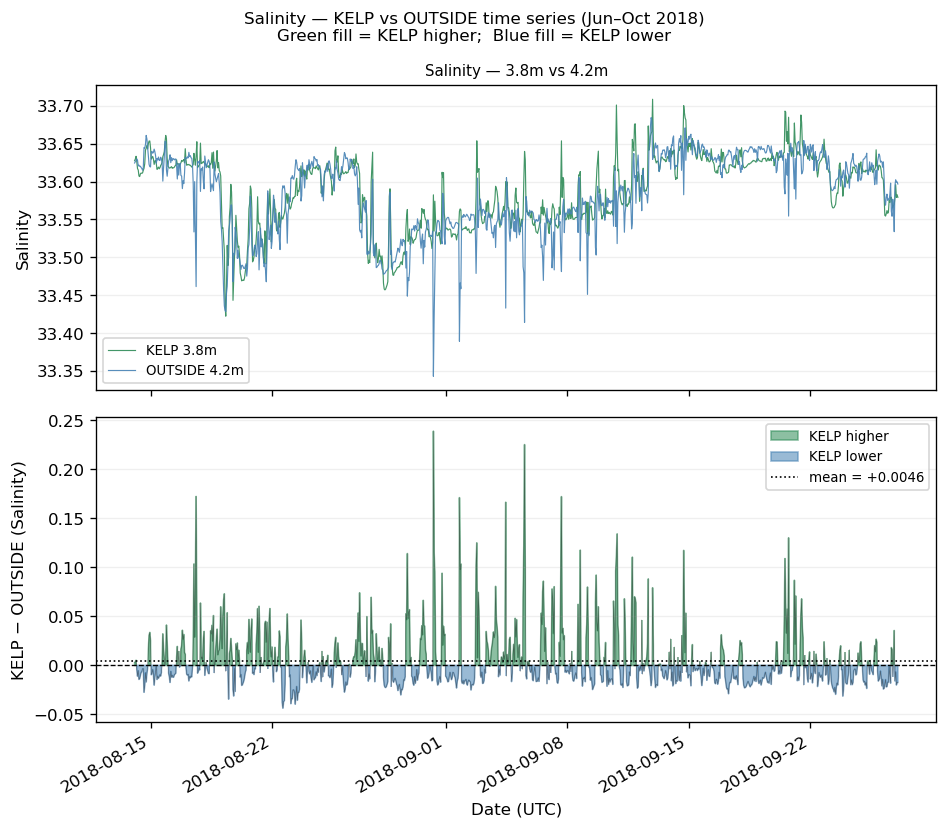

Inside-vs-outside summary statistics (KELP − OUTSIDE):
  Variable    KELP(m)  OUT(m)     n_K     n_O  KELP mean   OUT mean    Δ(K−O)
  ──────────────────────────────────────────────────────────────────────────────
  pH             3.8m    3.1m  24,380  19,830     8.0430     8.0863   -0.0433
  DO             3.8m    4.2m  24,380  31,842   256.7018   288.4054  -31.7037
  DO             4.7m    4.2m  30,765  31,842   266.5722   288.4054  -21.8332
  DO             8.9m    8.7m  32,670  31,842   215.9124   241.7508  -25.8384
  Salinity       3.8m    4.2m  24,380  12,650    33.6437    33.5840   +0.0597

PAR — unequal depths; daytime-only (PAR > 0) used for Section 2:
                                    KELP   OUTSIDE         depth
  depth from surface                 9.9m      17.7m
  all-time median (incl. night)    0.5608    1.6098  [misleading absolute values]
  daytime mean (PAR > 0)          4.5994   11.2281  [representative irradiance]
  n daytime obs                   20,797    24,124

In [8]:
# ── 1.7 Time series: pH, DO, Salinity — KELP vs OUTSIDE ──────────────────
# Hourly-resampled time series at closest available depth pairs.
# Top row = overlaid values; bottom row = KELP−OUTSIDE difference.
# Shows whether inside-outside differences are stable across the season
# or event-driven. Summary statistics printed below plots.
#
# Pairs:
#   pH:       KELP DID2 (3.8m) ↔ OUTSIDE DID3 (3.1m)  [only available pair]
#   DO:       KELP DID2 (3.8m) ↔ OUTSIDE DID4 (4.2m)  [shallow]
#             KELP DID3 (4.7m) ↔ OUTSIDE DID4 (4.2m)  [mid]
#             KELP DID8 (8.9m) ↔ OUTSIDE DID6 (8.7m)  [deep]
#   Salinity: KELP DID2 (3.8m) ↔ OUTSIDE DID4 (4.2m)  [only available pair]
#             OUTSIDE has only one salinity sensor. Despite similar depth from
#             surface (3.8m vs 4.2m), the sensors are at very different heights
#             above the seafloor: KELP 6.1m MAB vs OUTSIDE 13.5m MAB. Dense
#             upwelled water intrudes along the bottom — this mismatch means
#             salinity spike comparisons cannot be interpreted as a kelp effect.

TSERIES = {
    'pH': [
        ('KELP', 2, 'OUTSIDE', 3, '3.8m vs 3.1m'),
    ],
    'DO': [
        ('KELP', 2, 'OUTSIDE', 4, 'Shallow  3.8m vs 4.2m'),
        ('KELP', 3, 'OUTSIDE', 4, 'Mid      4.7m vs 4.2m'),
        ('KELP', 8, 'OUTSIDE', 6, 'Deep     8.9m vs 8.7m'),
    ],
    'Salinity': [
        ('KELP', 2, 'OUTSIDE', 4, '3.8m vs 4.2m'),
    ],
}

def get_hourly(mooring, did, var):
    return (df_moor.loc[(df_moor['Mooring_ID'] == mooring) & (df_moor['Depth_ID'] == did)]
            .set_index('datetime')[var]
            .dropna()
            .resample('1h').mean())

for var, pairs in TSERIES.items():
    n_cols = len(pairs)
    col_w = 7 if n_cols >= 3 else 8
    fig, axes = plt.subplots(2, n_cols, figsize=(col_w * n_cols, 7),
                             sharex='col', sharey='row')
    if n_cols == 1:
        axes = axes.reshape(2, 1)

    for col, (km, kid, om, oid, label) in enumerate(pairs):
        kd = get_depth(km, kid)
        od = get_depth(om, oid)
        k_ser = get_hourly(km, kid, var)
        o_ser = get_hourly(om, oid, var)
        common = k_ser.index.intersection(o_ser.index)
        k_al   = k_ser.reindex(common)
        o_al   = o_ser.reindex(common)
        diff   = k_al - o_al

        ax_t = axes[0, col]
        ax_t.plot(k_al.index, k_al.values, color='seagreen',  lw=0.7, alpha=0.9,
                  label=f'KELP {kd:.1f}m')
        ax_t.plot(o_al.index, o_al.values, color='steelblue', lw=0.7, alpha=0.9,
                  label=f'OUTSIDE {od:.1f}m')
        ax_t.set_title(f'{var} — {label}', fontsize=9)
        ax_t.set_ylabel(var)
        ax_t.legend(fontsize=8)
        ax_t.grid(axis='y', alpha=0.2)

        ax_d = axes[1, col]
        ax_d.fill_between(diff.index, diff.values, 0,
                          where=(diff.values >= 0), color='seagreen',  alpha=0.55,
                          label='KELP higher')
        ax_d.fill_between(diff.index, diff.values, 0,
                          where=(diff.values <  0), color='steelblue', alpha=0.55,
                          label='KELP lower')
        ax_d.plot(diff.index, diff.values, color='k', lw=0.4, alpha=0.4)
        ax_d.axhline(0,           color='k', lw=0.8, ls='--')
        ax_d.axhline(diff.mean(), color='k', lw=1.0, ls=':',
                     label=f'mean = {diff.mean():+.4f}')
        ax_d.set_ylabel(f'KELP − OUTSIDE ({var})')
        ax_d.set_xlabel('Date (UTC)')
        ax_d.legend(fontsize=8)
        ax_d.grid(axis='y', alpha=0.2)

    fig.autofmt_xdate()
    plt.suptitle(f'{var} — KELP vs OUTSIDE time series (Jun–Oct 2018)\n'
                 f'Green fill = KELP higher;  Blue fill = KELP lower',
                 fontsize=10)
    plt.tight_layout()
    plt.show()

# ── Summary statistics ─────────────────────────────────────────────────────
print('Inside-vs-outside summary statistics (KELP − OUTSIDE):')
print(f'  {"Variable":<10} {"KELP(m)":>8} {"OUT(m)":>7} {"n_K":>7} {"n_O":>7} '
      f'{"KELP mean":>10} {"OUT mean":>10} {"Δ(K−O)":>9}')
print('  ' + '─' * 78)
for var, km, kid, om, oid, _ in [p for v, pairs in TSERIES.items() for p in [(v, *q) for q in pairs]]:
    kd = get_depth(km, kid)
    od = get_depth(om, oid)
    k_vals = df_moor.loc[(df_moor['Mooring_ID']==km) & (df_moor['Depth_ID']==kid), var].dropna()
    o_vals = df_moor.loc[(df_moor['Mooring_ID']==om) & (df_moor['Depth_ID']==oid), var].dropna()
    if len(k_vals) > 10 and len(o_vals) > 10:
        delta = k_vals.mean() - o_vals.mean()
        print(f'  {var:<10} {kd:>7.1f}m {od:>6.1f}m {len(k_vals):>7,} {len(o_vals):>7,} '
              f'{k_vals.mean():>10.4f} {o_vals.mean():>10.4f} {delta:>+9.4f}')

# ── PAR — reported separately with daytime-only statistics ────────────────
# PAR is 0 at night by definition. An all-time median across all observations
# includes many nighttime zeros and produces misleadingly low absolute values.
# Daytime mean (PAR > 0) gives representative light-period irradiance.
# Note: sensors are at unequal depths (KELP 9.9m, OUTSIDE 17.7m) — the
# ratio captures both canopy attenuation and the depth difference; these
# cannot be separated without matched-depth sensors on both moorings.
kelp_par_all = df_moor.loc[(df_moor['Mooring_ID']=='KELP')    & (df_moor['Depth_ID']==9), 'PAR'].dropna()
out_par_all  = df_moor.loc[(df_moor['Mooring_ID']=='OUTSIDE') & (df_moor['Depth_ID']==9), 'PAR'].dropna()
kelp_par_day = kelp_par_all[kelp_par_all > 0]
out_par_day  = out_par_all[out_par_all > 0]
depth_diff   = get_depth('OUTSIDE', 9) - get_depth('KELP', 9)

print()
print('PAR — unequal depths; daytime-only (PAR > 0) used for Section 2:')
print(f'  {"":28} {"KELP":>9} {"OUTSIDE":>9}  {"depth":>12}')
print(f'  {"depth from surface":28} {get_depth("KELP",9):>9.1f}m {get_depth("OUTSIDE",9):>9.1f}m')
print(f'  {"all-time median (incl. night)":28} {kelp_par_all.median():>9.4f} {out_par_all.median():>9.4f}  [misleading absolute values]')
print(f'  {"daytime mean (PAR > 0)":28} {kelp_par_day.mean():>9.4f} {out_par_day.mean():>9.4f}  [representative irradiance]')
print(f'  {"n daytime obs":28} {len(kelp_par_day):>9,} {len(out_par_day):>9,}')
print(f'  KELP/OUTSIDE daytime mean: {kelp_par_day.mean()/out_par_day.mean():.2f}× '
      f'(KELP lower despite being {depth_diff:.1f}m shallower)')

## Section 2 — Sensor Recommendations for a Fixed Kelp-Bed Mooring

Based on BCO-DMO dataset 822549 (Hopkins Marine Station, Jun–Oct 2018): 9-depth paired
mooring, `KELP` (inside canopy) vs. `OUTSIDE` (~115m offshore), giant kelp (*Macrocystis
pyrifera*). Analysis follows [Hirsh et al. (2020)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2020JC016320).
Variables ranked by inside-vs-outside signal strength.

### Inside-vs-outside signal summary

| Variable | Observed Δ (KELP − OUTSIDE) | Signal type |
|---|---|---|
| PAR | 4.60 vs 11.23 μmol m⁻² s⁻¹ daytime mean (KELP 9.9m, OUTSIDE 17.7m) — KELP ~59% lower despite being 7.8m shallower; sensors at unequal depths | Direct canopy indicator — confirmed Hirsh et al. (2020) |
| pH (surface, ~0–3m) | +0.06 (discrete samples; Hirsh et al., 2020) — above sensor array, not in moored record | Photosynthetic buffering by kelp canopy; biologically driven diel cycle |
| pH (sub-canopy, 3.8m+) | −0.04 at 3.8m to −0.19 at 8.4m; flat diel cycle (Hirsh et al., 2020) | Canopy shading suppresses phytoplankton productivity at depth; physical advection dominates |
| DO | −22 to −32 μmol/kg across sub-canopy depth pairs (3.8–8.9m vs 4.2–8.7m) | Same physical and biological drivers as pH |
| Salinity | <0.06 PSU mean Δ; spike comparison confounded — OUTSIDE has only one salinity sensor (4.2m from surface, 13.5m above seafloor) vs KELP at 6.1m above seafloor; matched-MAB comparison not possible | Regional upwelling signal; sensor geometry prevents kelp-effect interpretation |
| Temperature | <0.2°C at all matched depths | Physical processes (canopy mixing, site depth); no kelp metabolic signal at this site |

### Recommended sensors, in priority order

**1. PAR (~5–10m depth)**
The only variable that unambiguously indicates canopy presence on its own. The KELP bottom
sensor (9.9m) records a daytime mean of 4.60 μmol m⁻² s⁻¹; the OUTSIDE bottom sensor
(17.7m) records 11.23 μmol m⁻² s⁻¹ — KELP reads ~59% lower despite being 7.8m shallower,
an inversion of the expected depth-attenuation relationship that is a direct signature of the
overhead canopy. Hirsh et al. (2020) confirm light attenuation was greater inside the kelp
forest despite the shallower depth. In practice, a healthy dense canopy keeps sub-canopy PAR
suppressed; an increase in measured PAR at depth is the canopy thinning or collapse signal,
providing continuous detection between satellite passes.

**2. pH — sensor depth determines what you measure** *(deploy if budget allows)*
Sensor depth is a deliberate design choice:
- **~1–2m**: captures photosynthetic pH elevation at the canopy surface (+0.06 vs. outside per
  discrete samples; Hirsh et al., 2020). Uninstrumented in the moored record — the paper
  estimates the kelp signal is limited to the top ~1–5m.
- **~8–10m**: captures sub-canopy conditions (Δ=−0.04 at 3.8m to −0.19 at 8.4m; Hirsh et al.,
  2020), driven by canopy shading and physical advection rather than kelp metabolism directly.
  Flat diel cycle confirms the signal at this depth is not biologically driven.

**3. DO (~8–10m depth)** *(deploy if budget allows)*
DO and pH are driven by the same physical and biological processes and are highly correlated
(R=0.75–0.90; Hirsh et al., 2020). DO is lower inside the kelp at sub-canopy depths (Δ=−22 to
−32 μmol/kg across the 3.8–8.9m depth range), consistent with the pH pattern. DO independently
captures hypoxia stress and O2 supersaturation events — surface O2 reached 180% saturation
inside the kelp canopy in late July (Hirsh et al., 2020) — which are ecologically significant
beyond what pH alone conveys. If budget requires choosing one chemistry sensor, pH is preferable
as it directly measures acidification stress; DO alone is the cheaper alternative that still
captures the inside-vs-outside contrast.

**4. CTD (temperature + salinity, standard package)**
Temperature shows no kelp metabolic signal here (Δ<0.2°C at matched depths; stratification
also comparable between sites — Section 1.6), which is why it ranks last. Even so, in-situ
temperature at canopy depth fills a gap satellite SST cannot: it captures sub-surface conditions
where thermal stress actually occurs (Rogers-Bennett & Catton, 2019). Salinity adds no
kelp-specific signal and is retained as part of a standard CTD package for upwelling regime
context only. Deploy at ~9m depth alongside the PAR sensor; a second thermistor at ~1m adds
surface temperature for stratification monitoring at low cost.

### Caveats

- This dataset covers one summer deployment (Jun–Oct 2018) of giant kelp at a single site.
  Whether bull kelp (*Nereocystis luetkeana*) in shallower, more upwelling-exposed habitat
  shows a stronger temperature signal or different chemistry patterns is unknown.
- The Jun–Oct deployment misses spring (Apr–Jun), when upwelling stress and kelp growth rates
  are both highest (Hirsh et al., 2020). The period with the greatest potential OA amelioration
  signal is therefore unsampled.
- The OUTSIDE mooring at 115m is a realistic local reference rather than far-field open
  ocean — the same scale as a practical two-buoy deployment. The signals observed here
  are therefore conservative estimates of inside-vs-outside contrast, not overestimates.
- The KELP mooring has no pH sensor above 3.8m; the surface buffering signal (+0.06) is from
  discrete grab samples only and is absent from the moored time series.

### References

- Hirsh, H.K., Nickols, K.J., Takeshita, Y., Traiger, S.B., Mucciarone, D.A., Monismith, S.,
  & Dunbar, R.B. (2020). Drivers of biogeochemical variability in a central California kelp
  forest: Implications for local amelioration of ocean acidification. *Journal of Geophysical
  Research: Oceans*, 125, e2020JC016320. https://doi.org/10.1029/2020JC016320
- Rogers-Bennett, L. & Catton, C.A. (2019). Marine heat wave and multiple stressors tip bull
  kelp forest to sea urchin barrens. *Scientific Reports*, 9, 15050.
  https://doi.org/10.1038/s41598-019-51114-y